## Amino Acid Class Tolerance Analysis

This analysis extends Prywes et al. (2025) by examining which amino acid classes 
are most destructive when introduced as mutations.

Key findings:
- Negatively charged residues (D, E) are most destructive: 37.9% dead mutants
- Nonpolar aliphatic residues (G, A, V, L, I, M) are most tolerated: 18.1% dead
- Introducing charged residues into hydrophobic cores or active sites 
  disrupts enzyme structure and catalysis

This complements Fig. 2 from the paper, which shows structural tolerance 
but does not explicitly break down results by amino acid physicochemical class.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"C:\Users\ilija\rubiscodms\41586_2024_8455_MOESM4_ESM.csv")

# definišemo klase aminokiselina
klase = {
    'Nonpolar aliphatic': list('GAVLIMП'),
    'Aromatic':           list('FYW'),
    'Polar uncharged':    list('STNQ'),
    'Positively charged': list('KRH'),
    'Negatively charged': list('DE'),
    'Special':            list('CGP')
}

# mapiranje svake aminokiseline na klasu
aa_to_class = {}
for klasa, aas in klase.items():
    for aa in aas:
        aa_to_class[aa] = klasa

df['aa_class'] = df['residue'].map(aa_to_class)

print(df[['mutant', 'residue', 'aa_class', 'Fitness']].head(10))
print(f"\nKlase: {df['aa_class'].value_counts()}")

  mutant residue            aa_class   Fitness
0    Q3Y       Y            Aromatic  0.397403
1    Q3C       C             Special  0.764382
2    Q3D       D  Negatively charged  0.451716
3    Q3E       E  Negatively charged  0.418180
4    Q3F       F            Aromatic  0.698228
5    Q3G       G             Special  0.094564
6    Q3H       H  Positively charged  0.887042
7    Q3I       I  Nonpolar aliphatic  0.800539
8    Q3K       K  Positively charged  0.814152
9    Q3A       A  Nonpolar aliphatic  0.649886

Klase: aa_class
Nonpolar aliphatic    2148
Polar uncharged       1770
Aromatic              1339
Positively charged    1329
Special               1306
Negatively charged     868
Name: count, dtype: int64


C:\Users\ilija\AppData\Local\Temp\ipykernel_11496\2660113052.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([k.replace(' ', '\n') for k in klase_redosled], fontsize=9)


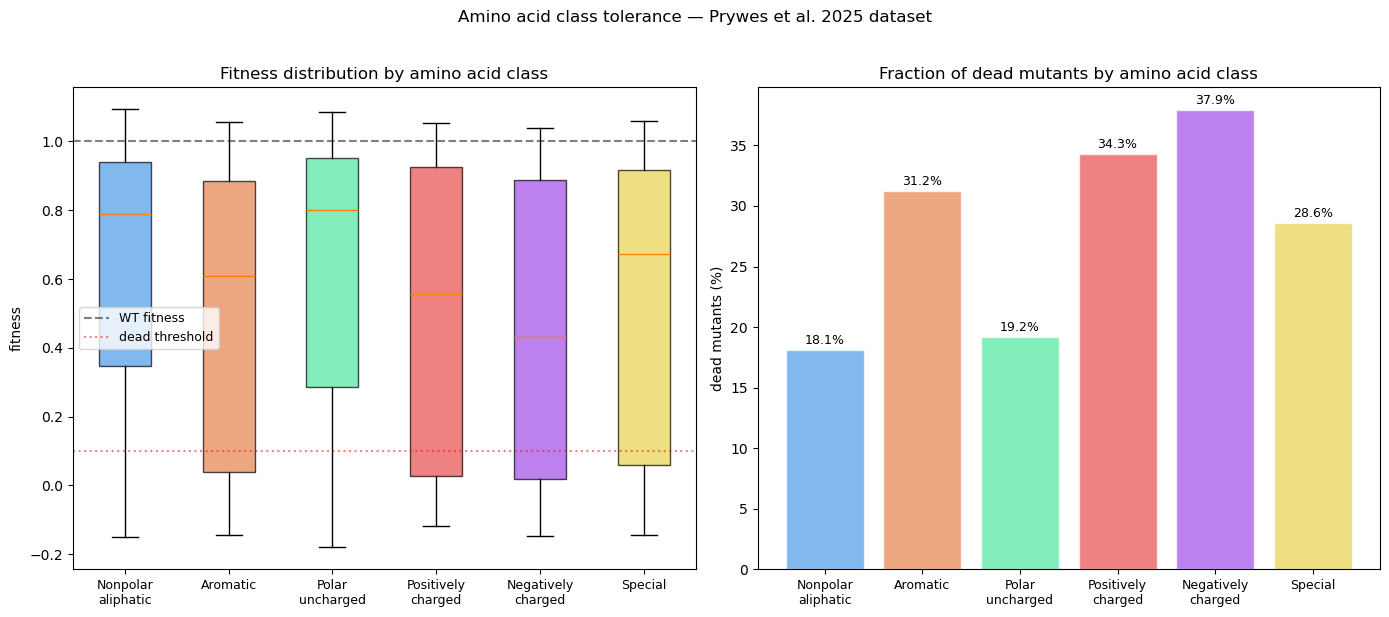


Dead mutant percentage by class:
  Nonpolar aliphatic       : 18.1%
  Aromatic                 : 31.2%
  Polar uncharged          : 19.2%
  Positively charged       : 34.3%
  Negatively charged       : 37.9%
  Special                  : 28.6%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafik 1: distribucija fitness po aminokiselinskoj klasi ---
ax1 = axes[0]

klase_redosled = [
    'Nonpolar aliphatic', 'Aromatic', 'Polar uncharged',
    'Positively charged', 'Negatively charged', 'Special'
]

boje = ['#4C9BE8', '#E8844C', '#4CE8A0', '#E84C4C', '#A04CE8', '#E8D44C']

data_za_box = [df[df['aa_class'] == k]['Fitness'].values for k in klase_redosled]

bp = ax1.boxplot(data_za_box, patch_artist=True, notch=False)

for patch, boja in zip(bp['boxes'], boje):
    patch.set_facecolor(boja)
    patch.set_alpha(0.7)

ax1.set_xticklabels([k.replace(' ', '\n') for k in klase_redosled], fontsize=9)
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='WT fitness')
ax1.axhline(y=0.1, color='red',   linestyle=':', alpha=0.5, label='dead threshold')
ax1.set_ylabel('fitness')
ax1.set_title('Fitness distribution by amino acid class')
ax1.legend(fontsize=9)

# --- Grafik 2: procenat dead mutanata po klasi ---
ax2 = axes[1]

dead_pct = []
for klasa in klase_redosled:
    subset = df[df['aa_class'] == klasa]
    pct = len(subset[subset['Fitness'] < 0.1]) / len(subset) * 100
    dead_pct.append(pct)

bars = ax2.bar(klase_redosled, dead_pct, color=boje, alpha=0.7, edgecolor='white')

ax2.set_xticklabels([k.replace(' ', '\n') for k in klase_redosled], fontsize=9)
ax2.set_ylabel('dead mutants (%)')
ax2.set_title('Fraction of dead mutants by amino acid class')

for bar, pct in zip(bars, dead_pct):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', fontsize=9)

plt.suptitle('Amino acid class tolerance — Prywes et al. 2025 dataset',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('aminoacid_class_analysis.png', dpi=200)
plt.show()

# ispiši ključne brojeve
print("\nDead mutant percentage by class:")
for klasa, pct in zip(klase_redosled, dead_pct):
    print(f"  {klasa:25s}: {pct:.1f}%")